In [1]:
from src.data.dataloader import generate_data
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.nn.functional as F
import os
import random

In [2]:
def seed_cpu(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    torch.manual_seed(seed)
    
    # Зажимаем вычисления в 1 поток (убирает разброс округления Float32 в OpenMP/MKL)
    torch.set_num_threads(1)
    
    # Принудительно включаем детерминированные алгоритмы
    torch.use_deterministic_algorithms(True, warn_only=True)

seed_cpu(42)

### Загрузка данных

In [3]:
X, y, amplitudes = generate_data(
    number_of_samples=20000,
    amp_range=(2, 40),
    length=200,
    noise_std=1
)

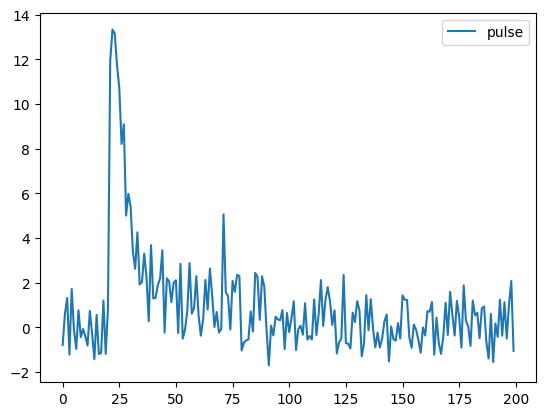

In [4]:
plt.plot(X[0], label='pulse')
plt.legend()
plt.show()

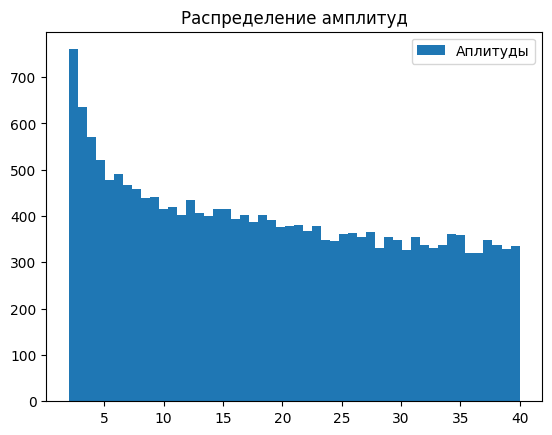

In [5]:
plt.hist(amplitudes, bins=50, label='Аплитуды')
plt.title('Распределение амплитуд')
plt.legend()
plt.show()

### Датасет

In [6]:
class PulseData(Dataset):
    def __init__(self, X, y, amplitudes):
        self.X = X
        self.y = y
        self.amplitudes = amplitudes

    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):

        return torch.tensor(self.X[idx] / np.max(self.X[idx]), dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.float32), self.amplitudes[idx]   

In [7]:
X_train, X_test, y_train, y_test, amplitudes_train, amplitudes_test = train_test_split(
    X, y, amplitudes,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
train_dataset = PulseData(X_train, y_train, amplitudes_train)
test_dataset = PulseData(X_test, y_test, amplitudes_test)

In [9]:
train_dataset = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataset = DataLoader(test_dataset, batch_size=64, shuffle=False)

### Модель

In [10]:
class VAENG(nn.Module):
    def __init__(self, out_channels_first=8, latent_dim=1,):
        super().__init__()
        self.out_channels_first = out_channels_first
        self.latent_dim = latent_dim

        self.encoder_backbone = nn.Sequential(
            #[64, 1, 200]
            nn.Conv1d(in_channels=1, out_channels=out_channels_first, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(out_channels_first),
            nn.ReLU(),

            #[64, 8, 100]
            nn.Conv1d(in_channels=out_channels_first, out_channels=out_channels_first*2, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(out_channels_first * 2),
            nn.ReLU(),

            # Сплющиваю
            nn.Flatten(),
            nn.Linear(out_channels_first * 2 * 50, 64),
            nn.ReLU(),
               
        )
        self.fc_mu = nn.Linear(64, latent_dim) 
        self.fc_logvar = nn.Linear(64, latent_dim) 

        self.decode_linear = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, out_channels_first * 2 * 50)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(out_channels_first*2, out_channels_first, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm1d(out_channels_first),
            nn.ReLU(),

            nn.ConvTranspose1d(out_channels_first, 1, kernel_size=5, stride=2, padding=2, output_padding=1),
          

        )

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu

    def forward(self, x):

        x = x.unsqueeze(1)
        h = self.encoder_backbone(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)

        x_recon = self.decode_linear(z)

        x_recon = x_recon.view(-1, self.out_channels_first * 2, 50)
        x_recon = self.decoder(x_recon)

        max_amp = torch.max(x_recon, dim=-1, keepdim=True).values
        x_recon = x_recon / (max_amp + 1e-8)

        return x_recon, mu, logvar                


In [11]:
def vae_loss_function(recon_x, x, mu, logvar, beta=1.0):

    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss
    

In [12]:
import torch.optim as optim
from tqdm import tqdm

In [13]:
model = VAENG(latent_dim=2, out_channels_first=10)

optimizer = optim.Adam(model.parameters(), lr=0.001)


In [14]:
num_epochs = 10
history_of_learn = {"train_loss_array": [],
                    "test_loss_array": []}
best_test_loss = float('inf')

In [15]:
for epoch in range(num_epochs):
    model.train()
    epoch_test_loss = 0.0
    epoch_train_loss = 0.0
    print(f"Epoch {epoch + 1}/{num_epochs}")

    for batch in tqdm(train_dataset):
        inputs = batch[0]

        optimizer.zero_grad()
        outputs, mu, logvar = model(inputs)
        loss, _, _ = vae_loss_function(outputs, inputs.float().unsqueeze(1), mu, logvar, beta=0.0001)

        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    
    model.eval()
    with torch.no_grad():
        for batch in tqdm(test_dataset):
            inputs = batch[0]
            outputs, mu, logvar = model(inputs)
            loss_test, _, _ = vae_loss_function(outputs, inputs.float().unsqueeze(1), mu, logvar, beta=0.0001)
            epoch_test_loss += loss_test.item()

    epoch_train_loss /= len(train_dataset)
    epoch_test_loss /= len(test_dataset)
    if best_test_loss > epoch_test_loss:
        best_test_loss = epoch_test_loss
        torch.save(model.state_dict(), 'checkpoints/best_vae_model.pth')
    print(f"Epoch {epoch + 1}/{num_epochs}, test loss {epoch_test_loss}, train loss {epoch_train_loss}")
    history_of_learn['train_loss_array'].append(epoch_train_loss)
    history_of_learn['test_loss_array'].append(epoch_test_loss)

model.load_state_dict(torch.load('checkpoints/best_vae_model.pth'))


Epoch 1/10


100%|██████████| 63/63 [00:00<00:00, 324.25it/s]


Epoch 1/10, test loss 0.014309016884201102, train loss 0.03147021328285336
Epoch 2/10


100%|██████████| 63/63 [00:00<00:00, 206.73it/s]


Epoch 2/10, test loss 0.012539957058689898, train loss 0.013291720733046531
Epoch 3/10


...

100%|██████████| 63/63 [00:00<00:00, 178.96it/s]


Epoch 9/10, test loss 0.0120793853088149, train loss 0.012214368106797338
Epoch 10/10


100%|██████████| 63/63 [00:00<00:00, 173.93it/s]

Epoch 10/10, test loss 0.012065692531270168, train loss 0.012185607867315412


<All keys matched successfully>

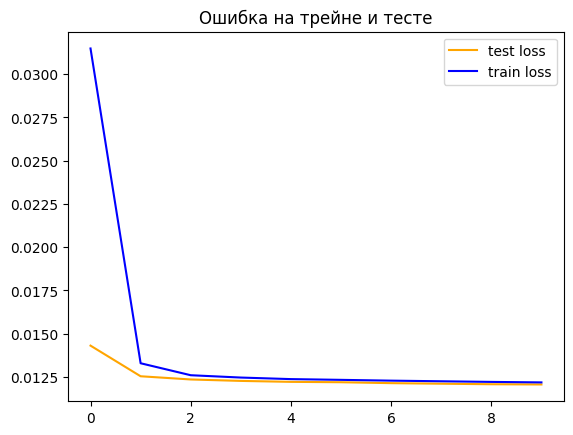

In [16]:
plt.plot(history_of_learn['test_loss_array'], color='orange', label='test loss')
plt.plot(history_of_learn['train_loss_array'], color='blue', label='train loss')
plt.title('Ошибка на трейне и тесте')
plt.legend()
plt.show()

In [17]:
import pandas as pd
from src.psd.psd import calculate_psd

In [18]:
data = pd.DataFrame(columns=['latent_vectors', 'whole_energy', 'psd', 'type'])

In [19]:
X_test_norm = X_test / np.max(X_test, axis=1).reshape(-1,1)

In [20]:
model.eval()
with torch.no_grad():
    outputs, mu, logvar = model(torch.tensor(X_test_norm, dtype=torch.float32))

In [21]:
outputs.shape

torch.Size([4000, 1, 200])

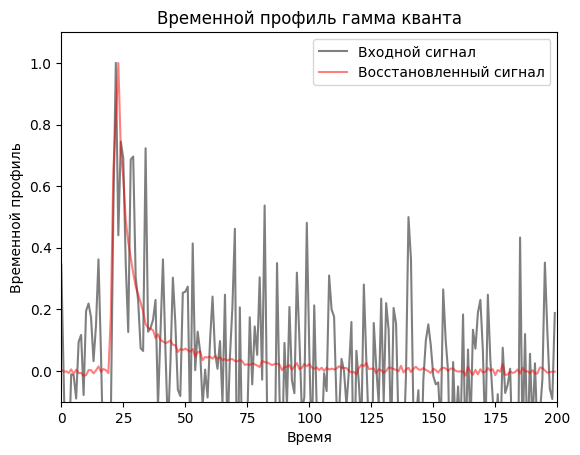

In [22]:
plt.plot(X_test[0] / np.max(X_test[0]), color='black', alpha=0.5, label='Входной сигнал')
plt.plot(outputs.numpy()[0].reshape(-1), color='red', alpha=0.5, label='Восстановленный сигнал')
plt.legend()
plt.title("Временной профиль гамма кванта")
plt.ylabel("Временной профиль")
plt.xlabel("Время")
plt.xlim(0, 200.0)
plt.ylim(-0.1, 1.1)
plt.show()

In [23]:
data = pd.DataFrame(columns=['latent_vectors', 'whole_energy', 'psd', 'type'])

In [24]:
data['latent_vectors'] = list(mu.numpy())
data['whole_energy'], data['psd'] = calculate_psd(X_test, tail_time=30, start_time=20)
data['type'] = y_test

In [25]:
from sklearn.metrics import accuracy_score

In [26]:
threshold = 0.57 
data['preds_psd_type'] = (data['psd'] < threshold).astype(int)

In [27]:
data.head()

,latent_vectors,whole_energy,psd,type,preds_psd_type
0,"[-1.1473608, 1.634289]",28.358079,0.138880,1.0,1
1,"[0.9459599, 0.94600517]",535.748013,0.629603,0.0,0
2,"[0.71572906, 1.0689042]",295.440157,0.638220,0.0,0
3,"[-0.747145, 0.8193937]",197.101136,0.493032,1.0,1
4,"[0.8560056, 0.9413261]",519.659078,0.632540,0.0,0


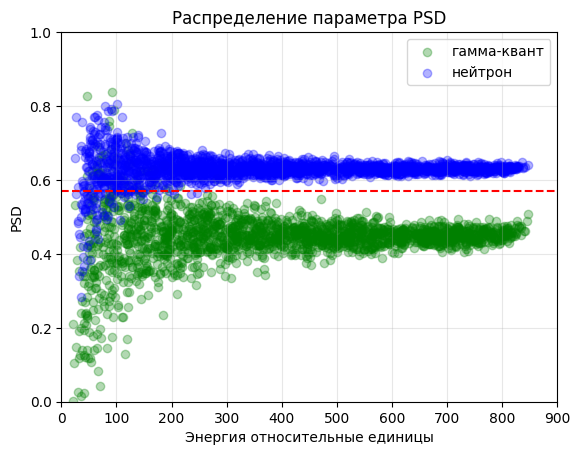

In [28]:
factor = data[data['type'] == 0]['whole_energy'].max() / data[data['type'] == 1]['whole_energy'].max()
plt.scatter(data[data['type'] == 1]['whole_energy'] * factor, data[data['type'] == 1]['psd'], color='green', alpha=0.3, label='гамма-квант')
plt.scatter(data[data['type'] == 0]['whole_energy'], data[data['type'] == 0]['psd'], color='blue', alpha=0.3,  label='нейтрон')
plt.axhline(0.57, linestyle='--', color='red')
plt.title('Распределение параметра PSD')
plt.xlim(0, 900)
plt.ylim(0, 1)
plt.legend()

plt.grid(alpha=0.3)
plt.ylabel('PSD')
plt.xlabel('Энергия относительные единицы')
plt.show()

In [29]:
data

,latent_vectors,whole_energy,psd,type,preds_psd_type
0,"[-1.1473608, 1.634289]",28.358079,0.138880,1.0,1
1,"[0.9459599, 0.94600517]",535.748013,0.629603,0.0,0
2,"[0.71572906, 1.0689042]",295.440157,0.638220,0.0,0
3,"[-0.747145, 0.8193937]",197.101136,0.493032,1.0,1
4,"[0.8560056, 0.9413261]",519.659078,0.632540,0.0,0
...,...,...,...,...,...
3995,"[-0.5768115, 0.67636985]",299.968943,0.482676,1.0,1
3996,"[-0.85438156, 0.7365802]",121.067087,0.425002,1.0,1
3997,"[-0.64090616, 1.0880499]",85.857620,0.381989,1.0,1
3998,"[-0.933057, 1.1371653]",96.782187,0.354861,1.0,1


In [30]:
accuracy = accuracy_score(data['type'], data['preds_psd_type'])
print(f"Accuracy score {accuracy}")

Accuracy score 0.966


In [31]:
first_latent_0 = np.vstack(data[data['type'] == 0]['latent_vectors'].values)[:, 0]
first_latent_1 = np.vstack(data[data['type'] == 1]['latent_vectors'].values)[:, 0]

In [32]:
second_latent_0 = np.vstack(data[data['type'] == 0]['latent_vectors'].values)[:, 1]
second_latent_1 = np.vstack(data[data['type'] == 1]['latent_vectors'].values)[:, 1]

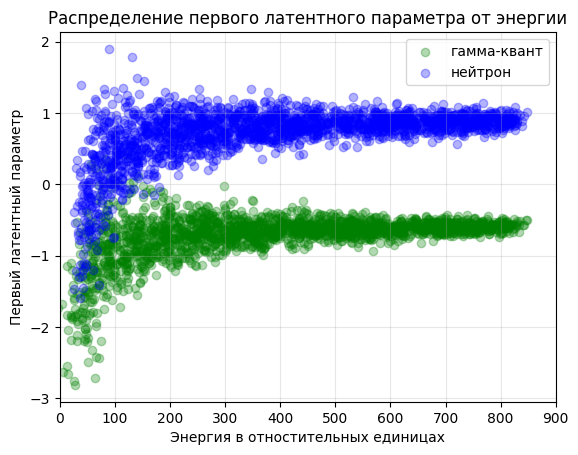

In [33]:

plt.scatter(data[data['type'] == 1]['whole_energy'] * factor, first_latent_1, color='green', alpha=0.3, label='гамма-квант')
plt.scatter(data[data['type'] == 0]['whole_energy'], first_latent_0, color='blue', alpha=0.3, label='нейтрон')
plt.title("Распределение первого латентного параметра от энергии")
plt.legend()
plt.ylabel("Первый латентный параметр")
plt.xlabel('Энергия в отностительных единицах')
plt.grid(alpha=0.3)
plt.xlim(0, 900)
plt.show()

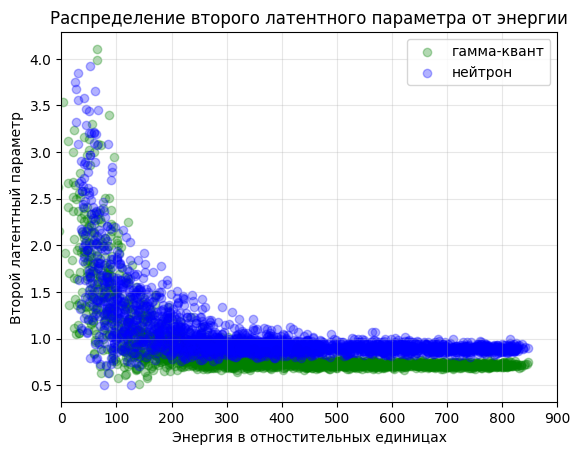

In [34]:
plt.scatter(data[data['type'] == 1]['whole_energy'] * factor, second_latent_1, color='green', alpha=0.3, label='гамма-квант')
plt.scatter(data[data['type'] == 0]['whole_energy'], second_latent_0, color='blue', alpha=0.3,  label='нейтрон')
plt.title("Распределение второго латентного параметра от энергии")
plt.legend()
plt.ylabel("Второй латентный параметр")
plt.xlabel('Энергия в отностительных единицах')
plt.grid(alpha=0.3)
plt.xlim(0, 900)
plt.show()

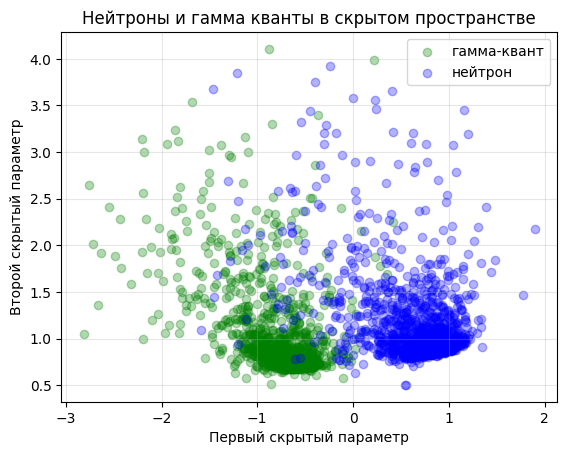

In [35]:
plt.scatter(first_latent_1, second_latent_1, color='green', alpha=0.3, label='гамма-квант')
plt.scatter(first_latent_0, second_latent_0, color='blue', alpha=0.3, label='нейтрон')
plt.title('Нейтроны и гамма кванты в скрытом пространстве')
plt.legend()
plt.xlabel('Первый скрытый параметр')
plt.ylabel('Второй скрытый параметр')
plt.grid(alpha=0.3)
plt.show()

In [36]:
from sklearn.cluster import KMeans


In [37]:
X_latent = np.vstack(data['latent_vectors'].values)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
predicted_labels = kmeans.fit_predict(X_latent)

if accuracy_score(data['type'], predicted_labels) < 0.5:
    predicted_labels = 1 - predicted_labels

data['preds_kmeans_type'] = predicted_labels

In [38]:
print(f"Accuracy score KMeans {accuracy_score(data['type'], data['preds_kmeans_type'])}")

Accuracy score KMeans 0.97025


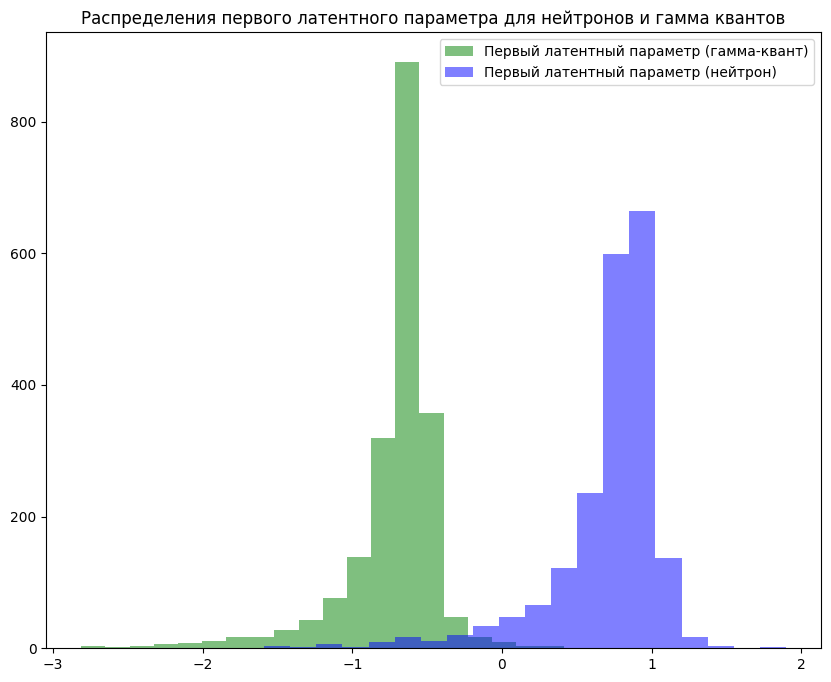

In [39]:
plt.figure(figsize=(10, 8))
plt.hist(X_latent[y_test == 1][:, 0], color='green', label='Первый латентный параметр (гамма-квант)', alpha=0.5, bins=20)
plt.hist(X_latent[y_test == 0][:, 0], color='blue', label='Первый латентный параметр (нейтрон)', alpha=0.5, bins=20)
plt.title('Распределения первого латентного параметра для нейтронов и гамма квантов')
plt.legend()
plt.show()


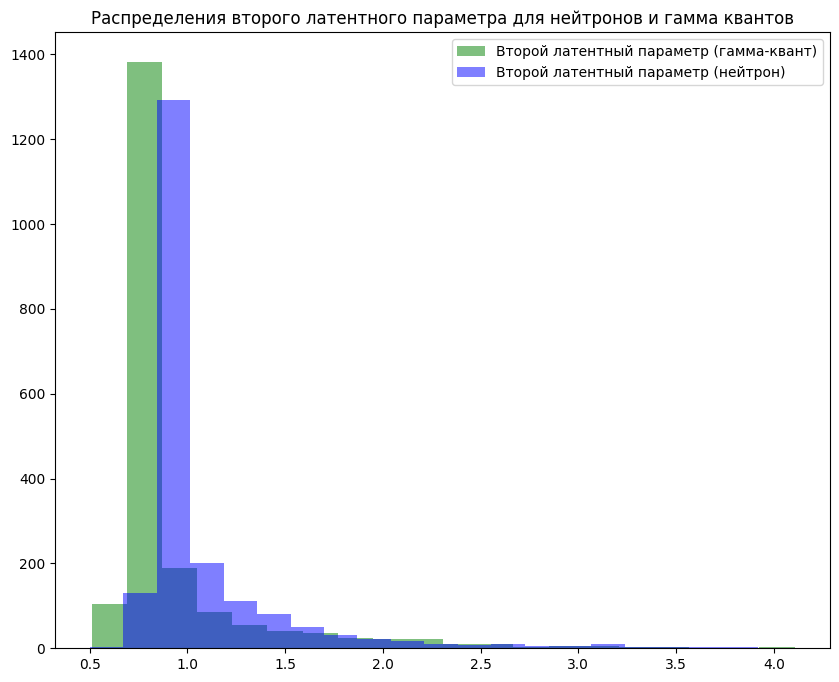

In [40]:
plt.figure(figsize=(10, 8))
plt.hist(X_latent[y_test == 1][:, 1], color='green', label='Второй латентный параметр (гамма-квант)', alpha=0.5, bins=20)
plt.hist(X_latent[y_test == 0][:, 1], color='blue', label='Второй латентный параметр (нейтрон)', alpha=0.5, bins=20)
plt.title('Распределения второго латентного параметра для нейтронов и гамма квантов')
plt.legend()
plt.show()